In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
texts = [
    "I love this product",
    "Amazing experience",
    "Very good service",
    "Excellent quality",
    "I hate this item",
    "Worst experience ever",
    "Bad service",
    "Very disappointing"
]

labels = [1,1,1,1,0,0,0,0]

In [4]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(texts).toarray()
y = np.array(labels)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.3333 - loss: 1.5789 - val_accuracy: 1.0000 - val_loss: 0.6044
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3333 - loss: 0.9939 - val_accuracy: 1.0000 - val_loss: 0.6038
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.6667 - loss: 0.5868 - val_accuracy: 1.0000 - val_loss: 0.6034
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step - accuracy: 0.3333 - loss: 1.0212 - val_accuracy: 1.0000 - val_loss: 0.6029
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 1.0000 - loss: 0.4245 - val_accuracy: 1.0000 - val_loss: 0.6022
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 1.0000 - loss: 0.2760 - val_accuracy: 1.0000 - val_loss: 0.6016
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8333 - loss: 0.4013 - val_accuracy: 1.0000 - val_loss: 0.6010
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 584ms/step - accuracy: 0.3333 - loss: 1.0168 - val_accuracy: 1.0000 - val_loss: 0.

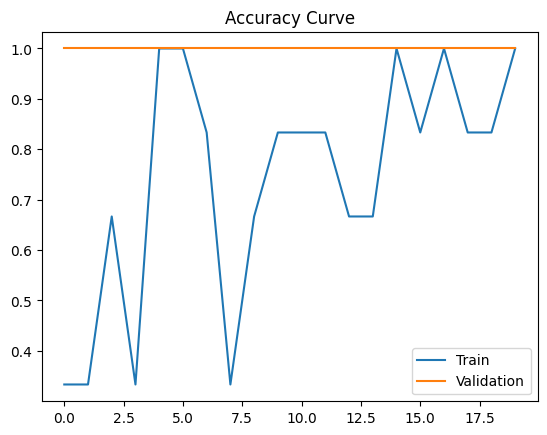

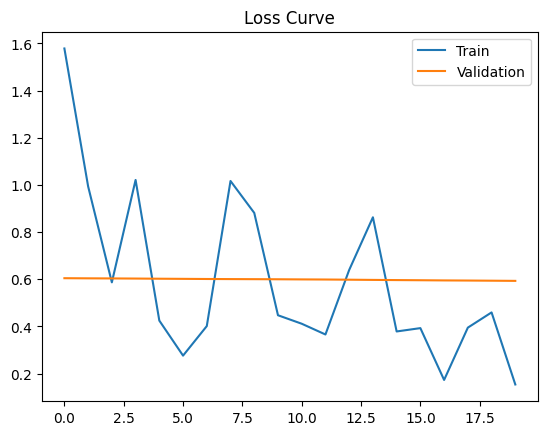

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Curve')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Curve')
plt.legend(['Train', 'Validation'])
plt.show()

In [10]:
sample = ["This product is excellent"]

sample_vec = vectorizer.transform(sample).toarray()

prediction = model.predict(sample_vec)

print("Confidence:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
Confidence: 0.5850774
Positive Sentiment
